# Set 12 - ARIMA, Prognosehorizont und Unsicherheit

**Lernziele:** ARIMA(p,d,q) einordnen, Modellwahl auf einem späteren Validierungsblock durchführen und Ein-Schritt-/Mehr-Schritt-Prognosen unterscheiden.

Für diesen Einstieg simulieren wir eine **stationäre tägliche AR(1)-Reihe ohne Saisonalität**. ARIMA ist ein klassisches Modell für zeitliche Abhängigkeit; saisonale Erweiterungen (SARIMA) sind ein Ausblick. Wir halten die erste Aufgabe absichtlich klein.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

kandidaten = [Path.cwd(), *Path.cwd().parents]
set_ordner = next((p for basis in kandidaten
                   for p in (basis, basis / "set12-zeitreihenanalyse")
                   if (p / "zeitreihen_tools.py").exists()), None)
if set_ordner is None:
    raise FileNotFoundError("Notebook bitte innerhalb des Kursordners starten.")
if str(set_ordner) not in sys.path:
    sys.path.insert(0, str(set_ordner))
from zeitreihen_tools import (FARBEN, plot_stil, zeitachse, synthetische_reihe,
                              lag_tabelle, metriken, lade_bike, lade_energie)
plot_stil()

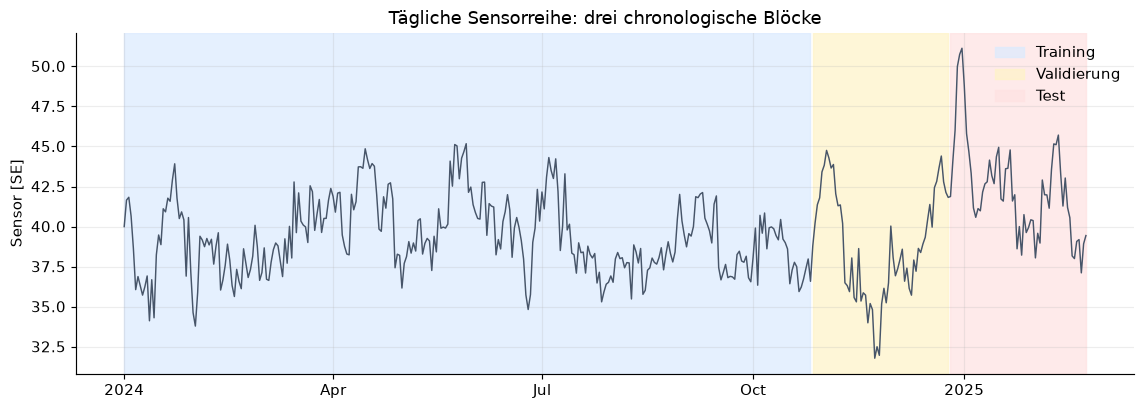

In [2]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

rng = np.random.default_rng(17)
werte = np.zeros(420)
for t in range(1,len(werte)):
    werte[t] = 0.8 * werte[t-1] + rng.normal(0,1.5)
y = pd.Series(40 + werte, index=pd.date_range("2024-01-01",periods=len(werte),freq="D"), name="Sensor")
training, validierung, test = y.iloc[:300], y.iloc[300:360], y.iloc[360:]
fig, ax = plt.subplots()
ax.plot(y, color=FARBEN["roh"], lw=1)
for serie,name,farbe in [(training,"Training",FARBEN["train"]),(validierung,"Validierung",FARBEN["val"]),(test,"Test",FARBEN["test"])]:
    ax.axvspan(serie.index[0],serie.index[-1],color=farbe,alpha=0.7,label=name)
ax.set(title="Tägliche Sensorreihe: drei chronologische Blöcke",ylabel="Sensor [SE]")
zeitachse(ax); ax.legend(); plt.tight_layout(); plt.show()

## 1. Die drei Parameter

| Parameter | Rolle |
|---|---|
| p | Anzahl autoregressiver Lags: Abhängigkeit von vergangenen Werten |
| d | Anzahl Differenzierungen vor dem Modellieren |
| q | Anzahl MA-Terme: Abhängigkeit von vergangenen Modellinnovationen |

Der MA-Teil in ARIMA ist **keine gleitende Mittelwertglättung**. Wir vergleichen nur drei kleine Kandidaten. Bei d=0 erlauben wir einen konstanten Term, bei d=1 einen linearen Trend im ursprünglichen Niveau (Drift nach Differenzierung). ACF/PACF geben Hinweise, ersetzen aber keine zeitliche Validierung.

In [3]:
kandidaten = [(1,0,0),(2,0,0),(1,1,0)]
fits = {}
val_prognosen = {}
for order in kandidaten:
    fit = ARIMA(training, order=order, trend="c" if order[1]==0 else "t").fit()
    fits[order] = fit
    val_prognosen[str(order)] = fit.forecast(steps=len(validierung))
val_tabelle = metriken(validierung,val_prognosen)
display(val_tabelle.round(3))
beste_order = min(kandidaten, key=lambda o:val_tabelle.loc[str(o),"MAE"])
print("Gewählte Order:",beste_order)
display(pd.DataFrame({"AIC Training":{str(o):f.aic for o,f in fits.items()}}).round(2))

,MAE,RMSE
Modell,,
"(1, 0, 0)",3.045,3.496
"(2, 0, 0)",3.074,3.537
"(1, 1, 0)",3.203,4.013


Gewählte Order: (1, 0, 0)


,AIC Training
"(1, 0, 0)",1087.88
"(2, 0, 0)",1080.77
"(1, 1, 0)",1097.67


**Informationsgrenze:** Alle 60 Validierungstage werden hier am Ende des Trainings in einem Schritt prognostiziert. Es fließen keine tatsächlichen Validierungswerte nach. Der Validierungs-MAE wählt die Order; AIC ist eine ergänzende Kennzahl des Fits und wird nicht auf dem Test optimiert.

## 2. Finale Mehr-Schritt-Prognose

Nach Modellwahl fitten wir Training plus Validierung. Für den gesamten Testblock bleibt der Prognoseursprung fest. Als vergleichbare Baseline bleibt der zuletzt beobachtete Wert über alle 60 zukünftigen Tage konstant. Die rollende Baseline aus Notebook 03 wäre für diese Aufgabe ein anderer Informationsstand.

In [4]:
historie = pd.concat([training,validierung])
final_fit = ARIMA(historie,order=beste_order,trend="c" if beste_order[1]==0 else "t").fit()
forecast = final_fit.get_forecast(steps=len(test))
prognose = forecast.predicted_mean
intervall = forecast.conf_int(alpha=0.05)
baseline = np.repeat(historie.iloc[-1],len(test))
display(metriken(test,{"Letzter Wert konstant":baseline,"ARIMA fester Ursprung":prognose}).round(3))

,MAE,RMSE
Modell,,
Letzter Wert konstant,2.318,3.08
ARIMA fester Ursprung,3.129,4.05


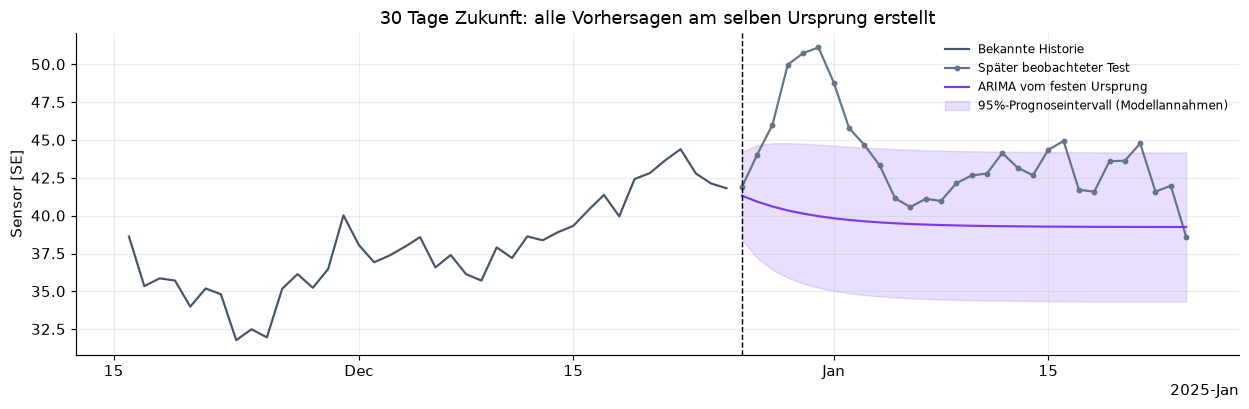

In [5]:
def zeige_horizont(horizont=30):
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(historie.iloc[-40:], color=FARBEN["roh"], label="Bekannte Historie")
    ax.plot(test.iloc[:horizont], color="#64748b", marker=".", label="Später beobachteter Test")
    ax.plot(prognose.iloc[:horizont], color=FARBEN["prognose"], label="ARIMA vom festen Ursprung")
    ax.fill_between(prognose.index[:horizont], intervall.iloc[:horizont,0], intervall.iloc[:horizont,1],
                    color=FARBEN["prognose"], alpha=0.16, label="95%-Prognoseintervall (Modellannahmen)")
    ax.axvline(test.index[0],color="black",ls="--",lw=1)
    ax.set(title=f"{horizont} Tage Zukunft: alle Vorhersagen am selben Ursprung erstellt",ylabel="Sensor [SE]")
    zeitachse(ax); ax.legend(fontsize=8); plt.tight_layout(); plt.show()
zeige_horizont()

In [6]:
import ipywidgets as widgets
horizont_regler=widgets.IntSlider(value=30,min=1,max=len(test),description="Tage",continuous_update=False)
horizont_output=widgets.interactive_output(zeige_horizont,{"horizont":horizont_regler})
display(horizont_regler,horizont_output)

IntSlider(value=30, continuous_update=False, description='Tage', max=60, min=1)

Output()

Das Prognoseintervall beschreibt die Unsicherheit zukünftiger Beobachtungen unter den Modellannahmen. Es berücksichtigt nicht automatisch einen Strukturbruch oder vollständige Parameterschätzunsicherheit. 95 % ist keine garantierte Trefferquote in jeder endlichen Testreihe.

## 3. Rollende Ein-Schritt-Prognose ist eine andere Aufgabe

Nun wird vor jedem nächsten Tag prognostiziert. Anschließend wird **erst nach der Vorhersage** der tatsächlich gemessene Wert zum Zustand hinzugefügt. Die ARIMA-Parameter bleiben mit `refit=False` fest. So vergleichen wir zwei Prognoseprotokolle, nicht zwei gleich schwierige Modelle.

,MAE,RMSE
Modell,,
"ARIMA rollend, 1 Tag",1.361,1.725
Letzter Wert rollend,1.337,1.692


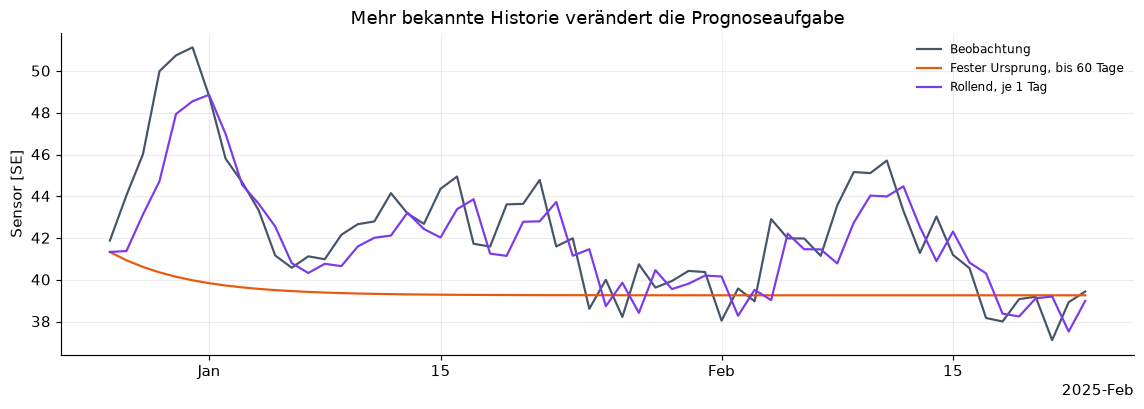

In [7]:
zustand = final_fit
rolling = []
for zeitpunkt, messwert in test.items():
    rolling.append(float(zustand.forecast(1).iloc[0]))
    neue_beobachtung = pd.Series([messwert],index=pd.date_range(zeitpunkt,periods=1,freq="D"),name=y.name)
    zustand = zustand.append(neue_beobachtung,refit=False)
rolling = pd.Series(rolling,index=test.index)
roll_baseline = y.shift(1).loc[test.index]
display(metriken(test,{"ARIMA rollend, 1 Tag":rolling,"Letzter Wert rollend":roll_baseline}).round(3))
fig,ax=plt.subplots()
ax.plot(test,color=FARBEN["roh"],label="Beobachtung")
ax.plot(prognose,color=FARBEN["trend"],label="Fester Ursprung, bis 60 Tage")
ax.plot(rolling,color=FARBEN["prognose"],label="Rollend, je 1 Tag")
ax.set(ylabel="Sensor [SE]",title="Mehr bekannte Historie verändert die Prognoseaufgabe")
zeitachse(ax); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 4. Restfehler prüfen

Verbleibende Autokorrelation in den Trainingsresiduen kann auf nicht modellierte Struktur hinweisen. Der Ljung-Box-Test ergänzt die Grafik; ein großer p-Wert beweist keine perfekte Modellierung. Hier wählen wir Lag 10 und berücksichtigen p+q bei den Freiheitsgraden.

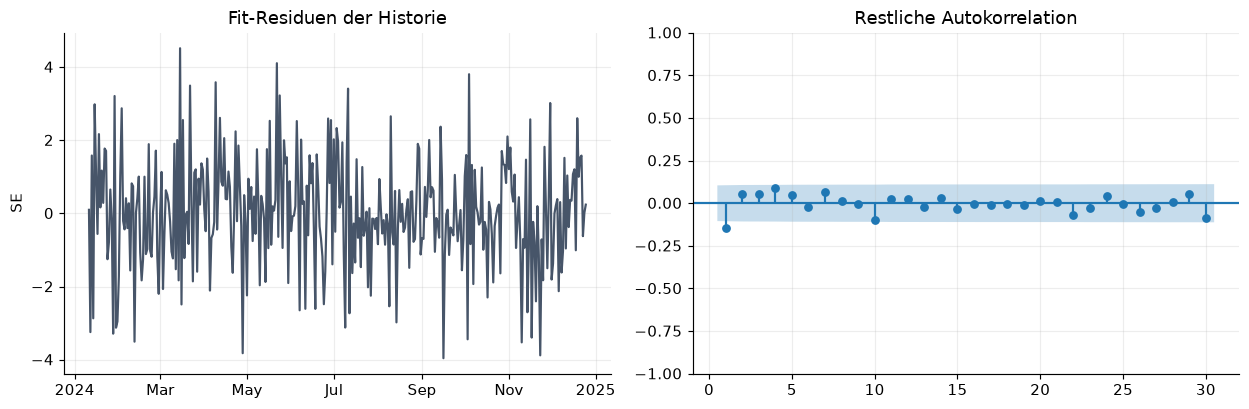

,lb_stat,lb_pvalue
10,18.39685,0.030839


In [8]:
residuen = final_fit.resid.iloc[max(10,final_fit.loglikelihood_burn):]
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(residuen,color=FARBEN["roh"]); axes[0].set(title="Fit-Residuen der Historie",ylabel="SE")
zeitachse(axes[0]); plot_acf(residuen,lags=30,ax=axes[1],zero=False)
axes[1].set_title("Restliche Autokorrelation")
plt.tight_layout(); plt.show()
display(acorr_ljungbox(residuen,lags=[10],model_df=beste_order[0]+beste_order[2],return_df=True))

## Kleine Aufgaben
1. Warum darf eine rollende Ein-Schritt-Prognose frühere Testmessungen verwenden?
2. Weshalb ist dieser Informationsstand bei einem festen 60-Tage-Forecast verboten?
3. Stelle den Horizont auf 1, 15 und 60 Tage. Wie verändert sich die Prognosekurve?
4. Welche zusätzliche Struktur wäre mit saisonalen ARIMA-Termen behandelbar?

Referenz: [statsmodels ARIMA](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html).